# OLS Fantasy Points Predictor — Methodology & Models

**v2 — corrected for lag.** The first version of this notebook trained on *same-season* pairs (a player's 2023/24 domestic stats paired with their 2023/24 UCL points) and used that model to predict an *unstarted* season — a mismatch, since same-season domestic and UCL form move together in real time (shared fitness, form, club situation), which is not the same thing as one season predicting the next. This version fixes that: every training pair now uses domestic season *S* to predict UCL season *S+1*, which is the actual task the model is deployed for (predicting an upcoming season from last season's data).

## Scope decisions (as agreed)
- **Target variable is reconstructed, not official** — UEFA does not publish historical fantasy points anywhere. Each player-season's UCL fantasy points are reconstructed by applying the known position-weighted scoring formula to that season's actual UCL match stats. This means the target omits bonuses the formula can't see from bulk stats: Player of the Match, penalties, cards, own goals. Accepted as a known limitation.
- **5 seasons of raw data pulled**: 2021/22 through 2025/26 — giving **4 valid lagged pairs** (21/22→22/23, 22/23→23/24, 23/24→24/25, 24/25→25/26). Capped at 5 seasons to avoid the pre-2024/25 competition format change (old group-stage-then-knockout vs. the current 36-team league phase) dominating the training data, and because advanced-stat tracking (tackles, xG) gets sparse further back.
- **16 domestic leagues** covering every league that feeds a 2026/27 UCL club.
- **No age, no domestic cups, no current-season (2026/27) data** in training — excluded by explicit scope choice.
- **Position tagging uses each player's *current* UEFA Fantasy position** — a limitation for older seasons, since a player active several years ago may have since retired or aged out of the current fantasy pool.
- **`league_strength`** = that country's UEFA association coefficient points for the *domestic input* season — a continuous team/league-quality control standing in for match-by-match fixture difficulty, which is deliberately not modeled (UCL league-phase draws are broad and roughly even, and clubs prioritize starting strong XIs in it).

## Data files used
- `regression_training_panel_lagged.csv` — the corrected, lagged panel this notebook fits on (1,053 player-seasons)
- `panels_by_k.json` — trailing-window panels (k = 1..4 prior seasons averaged) for the history-depth comparison in Section 5
- `predicted_fantasy_points_2627_lagged.csv` — this model's output, applied to the full current player pool's 2025/26 domestic form to predict 2026/27
- `regression_training_panel.csv` / `predicted_fantasy_points_2627.csv` — the **superseded same-season versions**, kept only for the side-by-side comparison in Section 3

In [1]:
import json
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

panel = pd.read_csv('regression_training_panel_lagged.csv')
panel.head()

,sofa_id,name,pos,dom_season,ucl_season,league,country,dom_g,dom_a,dom_tk,dom_cs,dom_sv,dom_rt,league_strength,target_ucl_fantasy_pts
0,556866,Gregor Kobel,GK,2122,2223,Bund,Germany,0,0,0,7,74,6.82,17.125,13
1,259117,Joshua Kimmich,MID,2122,2223,Bund,Germany,3,11,39,6,0,7.79,17.125,26
2,352370,Lucas Hernández,DEF,2122,2223,Bund,Germany,0,1,50,4,0,7.01,17.125,11
3,70996,Kevin De Bruyne,MID,2122,2223,PL,England,15,8,32,8,0,7.78,23.000,32
4,8959,Manuel Neuer,GK,2122,2223,Bund,Germany,0,0,2,10,63,6.93,17.125,15


## 1. Panel overview

In [2]:
print('Total lagged player-seasons:', len(panel))
print('\nBy position:')
print(panel['pos'].value_counts())
print('\nBy (domestic season \u2192 UCL season) pair:')
print(panel.groupby(['dom_season','ucl_season']).size())

Total lagged player-seasons: 1053

By position:
pos
MID    450
DEF    380
FWD    133
GK      90
Name: count, dtype: int64

By (domestic season → UCL season) pair:
dom_season  ucl_season
2122        2223          182
2223        2324          218
2324        2425          303
2425        2526          350
dtype: int64


## 2. Fit one OLS model per position (lagged, k=1)

HC1 robust standard errors throughout — residuals are non-normal and heavy-tailed (confirmed by Jarque-Bera below). **GK** drops `dom_g` and `dom_a`: both are near-zero-variance for goalkeepers, which makes their coefficients unstable rather than meaningful (94%+ of keeper-seasons have zero domestic assists — see the diagnostic cell).

In [3]:
gk = panel[panel['pos'] == 'GK']
print('GK dom_a value counts:')
print(gk['dom_a'].value_counts())
print(f"\n{(gk['dom_a'] == 0).mean():.1%} of GK player-seasons have zero domestic assists")

GK dom_a value counts:
dom_a
0    84
1     6
Name: count, dtype: int64

93.3% of GK player-seasons have zero domestic assists


In [4]:
FEATURES = {
    'GK':  ['dom_sv', 'dom_cs', 'dom_rt', 'league_strength'],
    'DEF': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
    'MID': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
    'FWD': ['dom_g', 'dom_a', 'dom_tk', 'dom_cs', 'dom_rt', 'league_strength'],
}

models = {}
for pos, feats in FEATURES.items():
    sub = panel[panel['pos'] == pos]
    X = sm.add_constant(sub[feats])
    y = sub['target_ucl_fantasy_pts']
    model = sm.OLS(y, X).fit(cov_type='HC1')
    models[pos] = model
    print(f'=== {pos} (n={len(sub)}) — R\u00b2={model.rsquared:.3f}, Adj. R\u00b2={model.rsquared_adj:.3f} ===')
    print(model.summary())
    print('\n')

=== GK (n=90) — R²=0.195, Adj. R²=0.157 ===
                              OLS Regression Results                              
Dep. Variable:     target_ucl_fantasy_pts   R-squared:                       0.195
Model:                                OLS   Adj. R-squared:                  0.157
Method:                     Least Squares   F-statistic:                     5.459
Date:                    Thu, 10 Sep 2026   Prob (F-statistic):           0.000583
Time:                            22:30:08   Log-Likelihood:                -337.18
No. Observations:                      90   AIC:                             684.4
Df Residuals:                          85   BIC:                             696.9
Df Model:                               4                                         
Covariance Type:                      HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

## 3. Same-season vs. lagged — how much of the original fit was just timing coincidence?

The same-season version of this model (domestic stats and UCL points from the *same* year) reported much higher R\u00b2 for every position. Rerunning it here side by side shows how much of that was genuine signal versus concurrent correlation that evaporates once the model has to actually look forward across an off-season.

In [5]:
panel_sameseason = pd.read_csv('regression_training_panel.csv')

comparison_rows = []
for pos, feats in FEATURES.items():
    sub_lag = panel[panel['pos'] == pos]
    Xl = sm.add_constant(sub_lag[feats]); yl = sub_lag['target_ucl_fantasy_pts']
    ml = sm.OLS(yl, Xl).fit(cov_type='HC1')

    sub_ss = panel_sameseason[panel_sameseason['pos'] == pos]
    Xs = sm.add_constant(sub_ss[feats]); ys = sub_ss['target_ucl_fantasy_pts']
    ms = sm.OLS(ys, Xs).fit(cov_type='HC1')

    comparison_rows.append({
        'Position': pos,
        'Same-season N': len(sub_ss), 'Same-season Adj_R2': round(ms.rsquared_adj, 3),
        'Lagged N': len(sub_lag), 'Lagged Adj_R2': round(ml.rsquared_adj, 3),
        'Drop': round(ms.rsquared_adj - ml.rsquared_adj, 3),
    })
comparison = pd.DataFrame(comparison_rows)
comparison

,Position,Same-season N,Same-season Adj_R2,Lagged N,Lagged Adj_R2,Drop
0,GK,110,0.375,90,0.157,0.218
1,DEF,476,0.218,380,0.062,0.156
2,MID,567,0.340,450,0.189,0.151
3,FWD,170,0.428,133,0.310,0.119


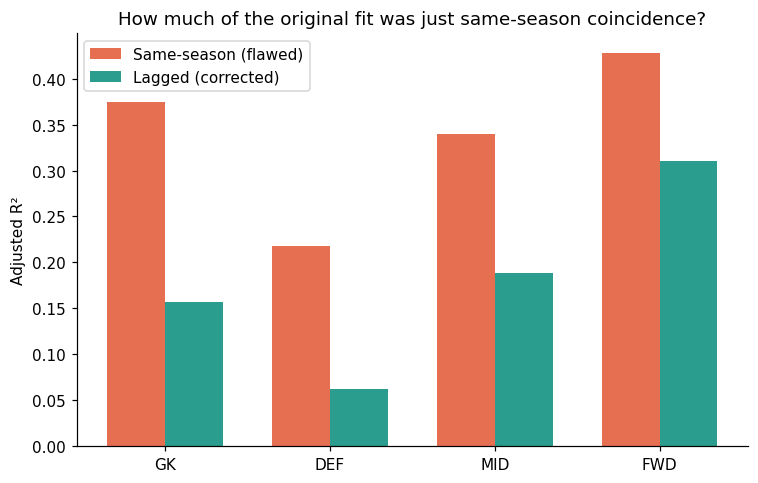

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['Same-season Adj_R2'], width, label='Same-season (flawed)', color='#e76f51')
ax.bar(x + width/2, comparison['Lagged Adj_R2'], width, label='Lagged (corrected)', color='#2a9d8f')
ax.set_xticks(x); ax.set_xticklabels(comparison['Position'])
ax.set_ylabel('Adjusted R\u00b2')
ax.set_title('How much of the original fit was just same-season coincidence?')
ax.legend()
plt.tight_layout()
plt.show()

**DEF is the starkest case**: same-season Adj. R\u00b2 \u2248 0.22 collapses to \u2248 0.06 once properly lagged — last season's domestic defensive stats tell you almost nothing about next season's UCL defensive returns. FWD holds up best of the four (still \u2248 0.31 lagged), meaning goal-scoring output is the most genuinely *persistent* signal across an off-season.

## 4. Coefficient grid — lagged models, all four positions

In [7]:
VAR_LABELS = {
    'const': 'Intercept',
    'dom_g': 'Domestic goals',
    'dom_a': 'Domestic assists',
    'dom_tk': 'Domestic tackles',
    'dom_cs': 'Domestic clean sheets',
    'dom_sv': 'Domestic saves',
    'dom_rt': 'Domestic avg. rating',
    'league_strength': "League's UEFA coefficient (domestic input season)",
}

rows = []
for pos, model in models.items():
    for var in model.params.index:
        rows.append({
            'Position': pos, 'Variable': var, 'Description': VAR_LABELS.get(var, var),
            'Beta': round(model.params[var], 4), 'StdErr_HC1': round(model.bse[var], 4),
            'z': round(model.tvalues[var], 3), 'p': round(model.pvalues[var], 4),
            'CI_low': round(model.conf_int().loc[var, 0], 3), 'CI_high': round(model.conf_int().loc[var, 1], 3),
            'Significant_at_05': model.pvalues[var] < 0.05,
        })
coef_grid = pd.DataFrame(rows)
coef_grid.to_csv('regression_model_coefficients_lagged.csv', index=False)
coef_grid

,Position,Variable,Description,Beta,StdErr_HC1,z,p,CI_low,CI_high,Significant_at_05
0,GK,const,Intercept,9.1496,4.0284,2.271,0.0231,1.254,17.045,True
1,GK,dom_sv,Domestic saves,0.0019,0.0365,0.051,0.9593,-0.070,0.073,False
2,GK,dom_cs,Domestic clean sheets,0.9502,0.3053,3.113,0.0019,0.352,1.548,True
3,GK,dom_rt,Domestic avg. rating,-0.6768,0.6811,-0.994,0.3204,-2.012,0.658,False
4,GK,league_strength,League's UEFA coefficient (domestic input season),0.1127,0.2561,0.440,0.6598,-0.389,0.615,False
5,DEF,const,Intercept,-2.8854,7.8798,-0.366,0.7142,-18.330,12.559,False
6,DEF,dom_g,Domestic goals,0.8600,0.3793,2.267,0.0234,0.117,1.603,True
7,DEF,dom_a,Domestic assists,0.5147,0.3376,1.524,0.1274,-0.147,1.176,False
8,DEF,dom_tk,Domestic tackles,0.0073,0.0349,0.209,0.8348,-0.061,0.076,False
9,DEF,dom_cs,Domestic clean sheets,0.2497,0.1343,1.859,0.0630,-0.014,0.513,False


**What survives forward-prediction**: `dom_g` (goals) is significant for DEF, MID, and FWD — the single most robust predictor across positions. `dom_tk` (tackles) loses significance everywhere once lagged (it was significant same-season — a sign it measures momentary activity, not a transferable skill). `league_strength` only clears significance cleanly for MID.

## 5. Does more historical depth help? (trailing k-season windows)

Instead of a single prior season, average domestic stats over the trailing *k* seasons (k=1..4, the max our 5 pulled seasons allow) and see whether more history improves the fit — trading sample size for more signal per observation as k grows.

In [8]:
with open('panels_by_k.json', encoding='utf-8') as f:
    panels_by_k = json.load(f)

k_rows = []
for k_str, prows in panels_by_k.items():
    k = int(k_str)
    dfk = pd.DataFrame(prows)
    for pos, feats in FEATURES.items():
        sub = dfk[dfk['pos'] == pos] if len(dfk) else dfk
        n = len(sub)
        if n < len(feats) + 5:
            k_rows.append({'k': k, 'pos': pos, 'n': n, 'r2': None, 'adj_r2': None})
            continue
        X = sm.add_constant(sub[feats]); y = sub['target_ucl_fantasy_pts']
        m = sm.OLS(y, X).fit(cov_type='HC1')
        k_rows.append({'k': k, 'pos': pos, 'n': n, 'r2': round(m.rsquared, 3), 'adj_r2': round(m.rsquared_adj, 3)})

k_summary = pd.DataFrame(k_rows).sort_values(['pos', 'k'])
k_summary.to_csv('k_window_comparison.csv', index=False)
k_summary

,k,pos,n,r2,adj_r2
1,1,DEF,380,0.077,0.062
5,2,DEF,283,0.155,0.137
9,3,DEF,191,0.173,0.147
13,4,DEF,93,0.222,0.167
3,1,FWD,133,0.341,0.310
7,2,FWD,94,0.382,0.339
11,3,FWD,60,0.377,0.307
15,4,FWD,28,0.749,0.677
0,1,GK,90,0.195,0.157
4,2,GK,69,0.147,0.094


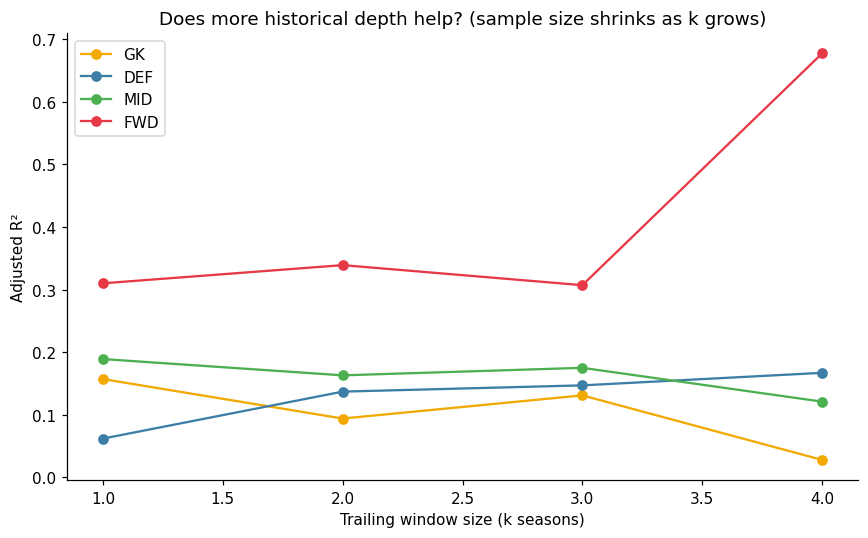

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'GK': '#f2a900', 'DEF': '#3d7ea6', 'MID': '#4caf50', 'FWD': '#e63946'}
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    sub = k_summary[(k_summary['pos'] == pos) & (k_summary['adj_r2'].notna())]
    ax.plot(sub['k'], sub['adj_r2'], marker='o', label=pos, color=colors[pos])
ax.set_xlabel('Trailing window size (k seasons)')
ax.set_ylabel('Adjusted R\u00b2')
ax.set_title('Does more historical depth help? (sample size shrinks as k grows)')
ax.legend()
plt.tight_layout()
plt.show()

**Read this carefully — not every line here is trustworthy.** DEF shows a genuine, steady improvement as k grows (Adj. R\u00b2 0.062 → 0.167) — the clearest real "more history helps" signal, plausible since single-season defensive output is noisy but multi-season averages smooth it out. MID stays essentially flat. FWD and GK's k=4 jumps look dramatic but rest on tiny samples (FWD n=28, GK n=24, against 5–7 parameters each) — that's very likely overfitting, not a real effect, and should not be trusted or acted on.

## 6. Predicted 2026/27 UCL fantasy points (lagged model, k=1)

Generated by feeding each current player's actual 2025/26 domestic-season stats + that league's 2025/26 UEFA coefficient into the lagged model for their position — exactly the forward-looking task the model was trained for this time.

In [10]:
preds = pd.read_csv('predicted_fantasy_points_2627_lagged.csv')
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    print(f'--- Top 10 {pos} ---')
    display(preds[preds['Position'] == pos].sort_values('PredictedUCLFantasyPts_Lagged', ascending=False).head(10))

--- Top 10 GK ---


,Name,Position,Team,League,PredictedUCLFantasyPts_Lagged
452,David Raya,GK,Arsenal,PL,25.88
453,Diogo Costa,GK,FC Porto,Portugal,24.85
454,Jean Butez,GK,Como,SerieA,24.65
455,Mile Svilar,GK,AS Roma,SerieA,23.81
456,Thomas Strakosha,GK,AEK Athens,Greece,23.15
457,Gianluigi Donnarumma,GK,Manchester City,PL,22.03
458,Gregor Kobel,GK,Borussia Dortmund,Bund,21.19
459,Joan García,GK,FC Barcelona,LaLiga,21.07
460,Yann Sommer,GK,Inter,SerieA,20.98
461,Dmytro Riznyk,GK,Shakhtar Donetsk,Ukraine,20.65


--- Top 10 DEF ---


,Name,Position,Team,League,PredictedUCLFantasyPts_Lagged
0,Federico Dimarco,DEF,Inter,SerieA,26.72
1,Alejandro Grimaldo,DEF,Bayer 04 Leverkusen,Bund,21.78
2,Nico O'Reilly,DEF,Manchester City,PL,18.68
3,Julian Ryerson,DEF,Borussia Dortmund,Bund,18.63
4,Carlos Romero,DEF,Espanyol,LaLiga,18.56
5,Marc Guéhi,DEF,Manchester City,PL,18.29
6,Jurriën Timber,DEF,Arsenal,PL,18.27
7,Virgil van Dijk,DEF,Liverpool FC,PL,18.11
8,David Raum,DEF,RB Leipzig,Bund,17.73
9,Konrad Laimer,DEF,FC Bayern München,Bund,17.65


--- Top 10 MID ---


,Name,Position,Team,League,PredictedUCLFantasyPts_Lagged
536,Christos Tzolis,MID,Club Brugge KV,Belgium,33.99
537,Michael Olise,MID,FC Bayern München,Bund,32.05
538,Bruno Fernandes,MID,Manchester United,PL,30.59
539,Lamine Yamal,MID,FC Barcelona,LaLiga,28.50
540,Luis Díaz,MID,FC Bayern München,Bund,28.18
541,Mika Godts,MID,AFC Ajax,Ered,26.65
542,Antoine Semenyo,MID,Manchester City,PL,26.52
543,Vinícius Júnior,MID,Real Madrid,LaLiga,24.16
544,Christoph Baumgartner,MID,RB Leipzig,Bund,23.95
545,Mason Greenwood,MID,Olympique de Marseille,L1,23.81


--- Top 10 FWD ---


,Name,Position,Team,League,PredictedUCLFantasyPts_Lagged
305,Harry Kane,FWD,FC Bayern München,Bund,34.90
306,Erling Haaland,FWD,Manchester City,PL,33.77
307,Kylian Mbappé,FWD,Real Madrid,LaLiga,30.46
308,Vedat Muriqi,FWD,Mallorca,LaLiga,25.60
309,Ayase Ueda,FWD,Feyenoord,Ered,23.18
310,Serhou Guirassy,FWD,Borussia Dortmund,Bund,22.83
311,Deniz Undav,FWD,VfB Stuttgart,Bund,20.77
312,Ollie Watkins,FWD,Aston Villa,PL,20.38
313,Viktor Gyökeres,FWD,Arsenal,PL,20.27
314,Ferran Torres,FWD,FC Barcelona,LaLiga,18.33


## 7. Known limitations

- **Reconstructed target, not official fantasy points** — missing Player of the Match, penalty, and card bonuses.
- **No age control** — identical domestic stat lines get identical predictions regardless of a 22- vs. 34-year-old.
- **No fixture difficulty / rotation risk** — `league_strength` is season-level, not match-level.
- **No transfer/new-club adjustment** — a player's 2025/26 stats may be from a club/league/role they've since left (e.g. Grimaldo's inputs here are from Bayer Leverkusen, not his 2026/27 club).
- **DEF is the weakest-fitting model even after correction** (Adj. R\u00b2 \u2248 0.06 at k=1) — forward-predicting defensive UCL output from domestic stats alone is genuinely hard; Section 5 suggests a longer trailing window (k=3–4) is the one lever that helps here.
- **Small samples at higher k for GK/FWD** — the k=4 results for those two positions should not be trusted or used; sample sizes (24–28) are too small relative to the number of predictors.